In [1]:
import numpy as np
import pandas as pd
from RecoUtils import tidyHits, CellIDLayerMapper, TimeZMapper, vec3d2mat
from podio.root_io import Reader
from plotnine.ggplot import ggplot
from plotnine import aes, facet_wrap, geom_point, theme
from datar.all import tibble, mutate, if_else, f, select
from megat import getIdConverter

compton_event_path = "./compton_digi.root"
reader = Reader(compton_event_path)

events = reader.get("events")

Module libc not found.
Info in <TGeoManager>: Changing system of units to Geant4 units (mm, ns, MeV).


Welcome to JupyROOT 6.28/06


/opt/podio/v00-17-02/python/podio/EventStore.py:4: FutureWarning: The EventStore based I/O model is deprecated and will be removed. Switch to the Frame based model.
  warnings.warn("The EventStore based I/O model is deprecated and will be removed. Switch to the Frame based model.",


In [2]:
event = events[42]
hits = event.get("TpcWaveformHits")

df = tidyHits(hits, "RawTimeSeries")

In [3]:
from SplineFit import SplineFit

In [4]:
dfp = df[df["layer"] == 0][["x", "z"]]

p1 = (
    ggplot(dfp, aes("x", "z"))
     + geom_point(color="lightblue", alpha=.9, size=.3)
     + theme(figure_size=(6, 6))
)
data = df[df["layer"] == 0][["x", "z"]].to_numpy()

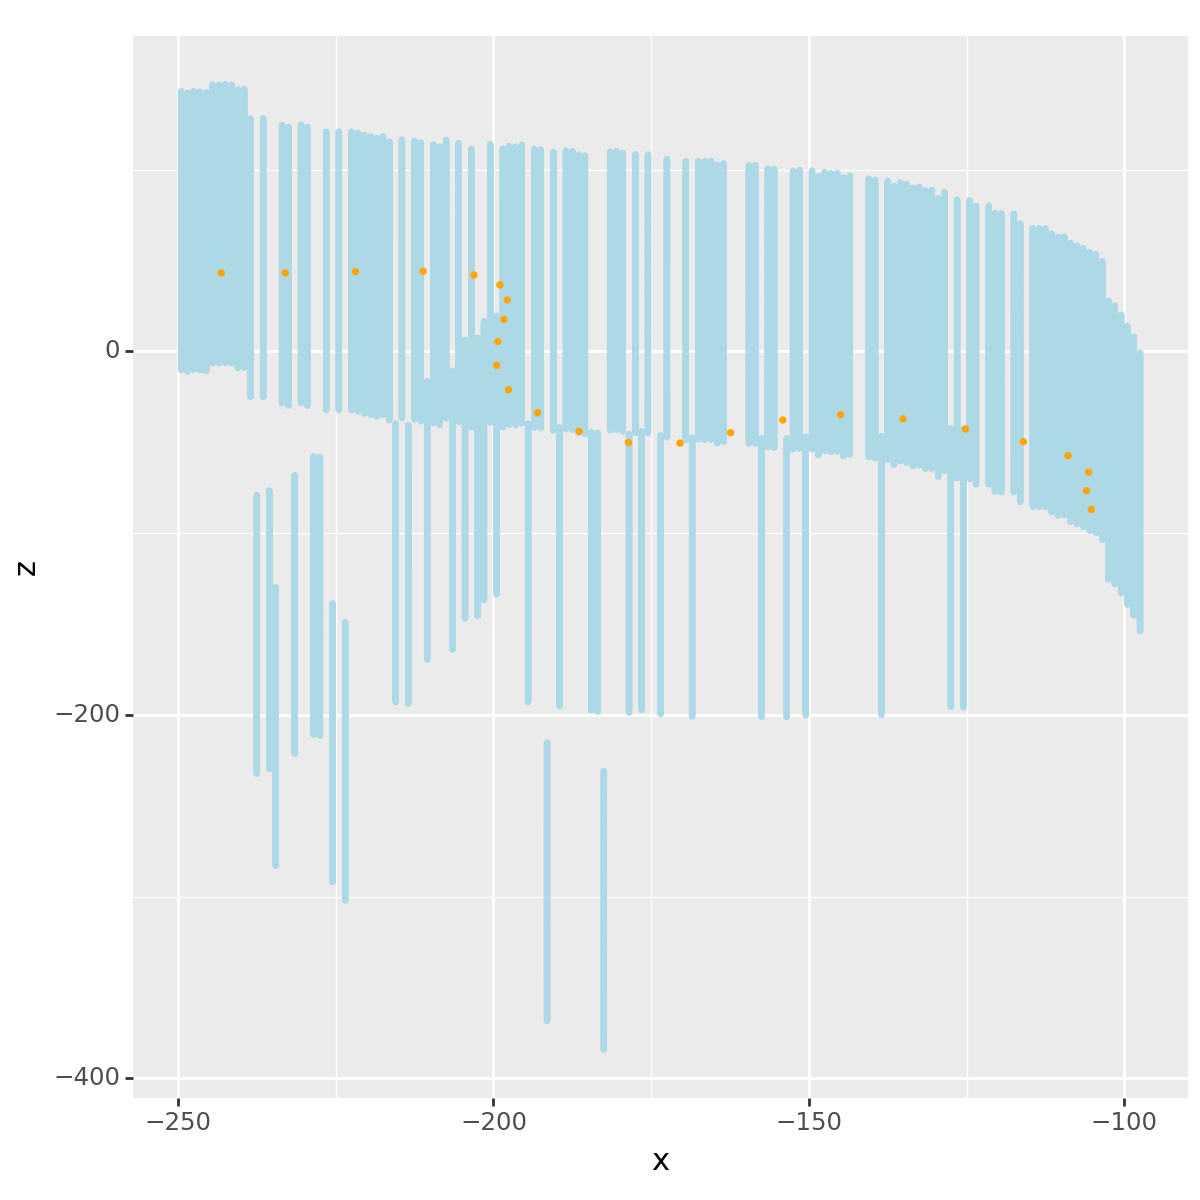

<Figure Size: (600 x 600)>

In [5]:
fit = SplineFit(data, np.zeros(1), radius = 20.)
fit.build_clusters(10000)
fit.order()
oc = fit.oc

dfc = pd.DataFrame(oc.value(np.arange(0, 1, 0.04)), columns=["x", "z"])

p1 + geom_point(data=dfc, color = "orange", size = .5)

In [6]:
from plotnine import theme_set, theme_linedraw

theme_set(theme_linedraw())

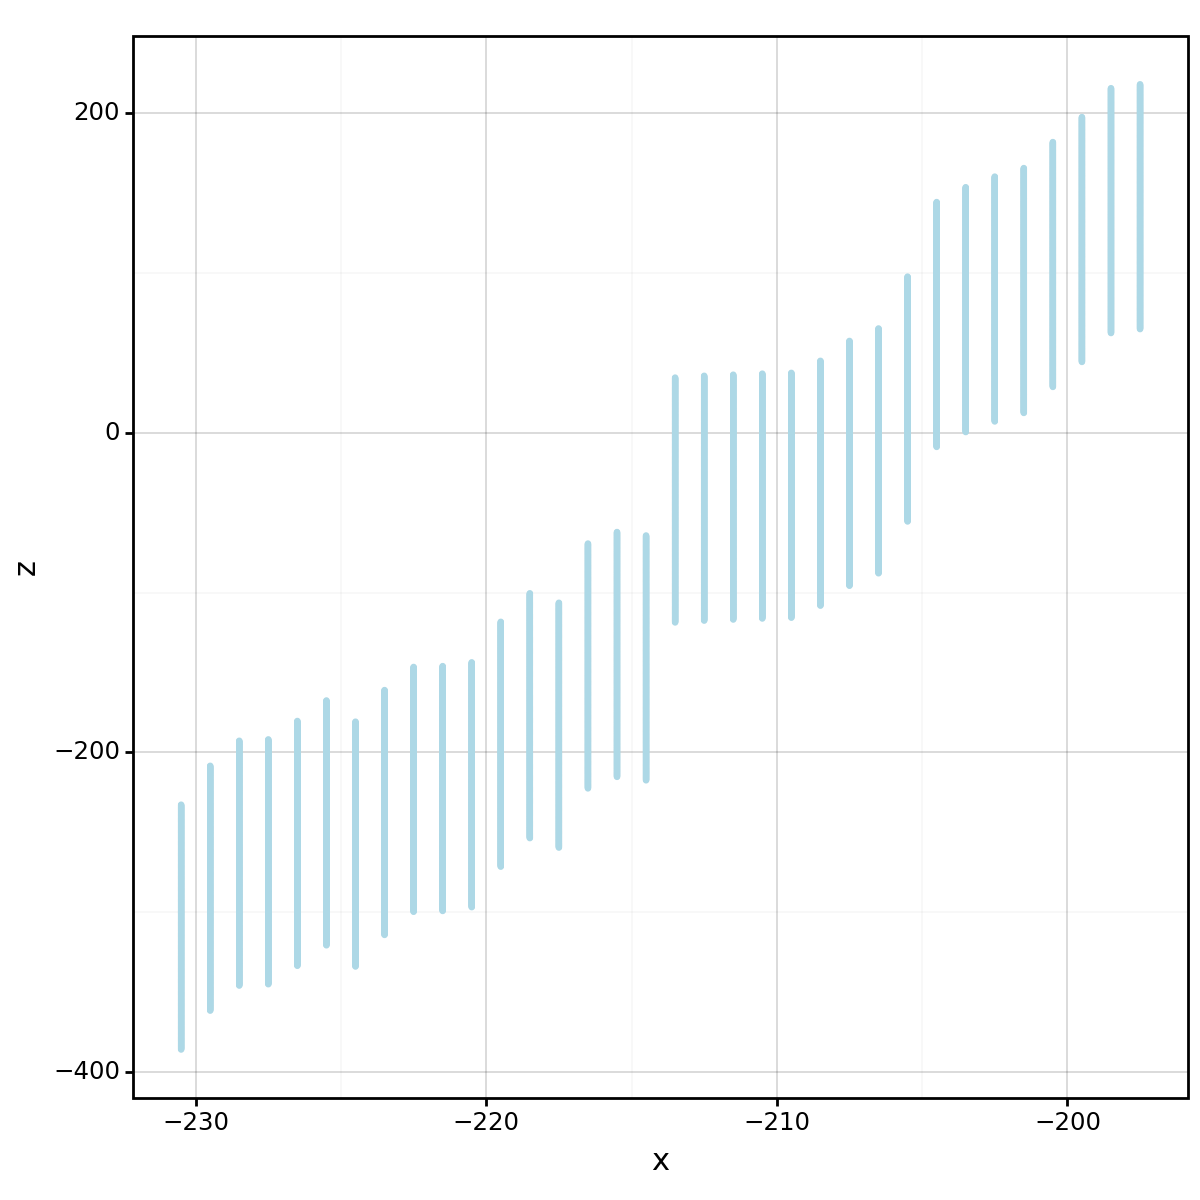

<Figure Size: (600 x 600)>

In [7]:
event = events[70]
df = tidyHits(event.get("TpcWaveformHits"), "RawTimeSeries")

dfp = df[df["layer"] == 0][["x", "z"]]

p1 = (
    ggplot(dfp, aes("x", "z"))
    + geom_point(color="lightblue", alpha=0.9, size=0.3)
    + theme(figure_size=(6, 6))
)
p1

17408
22


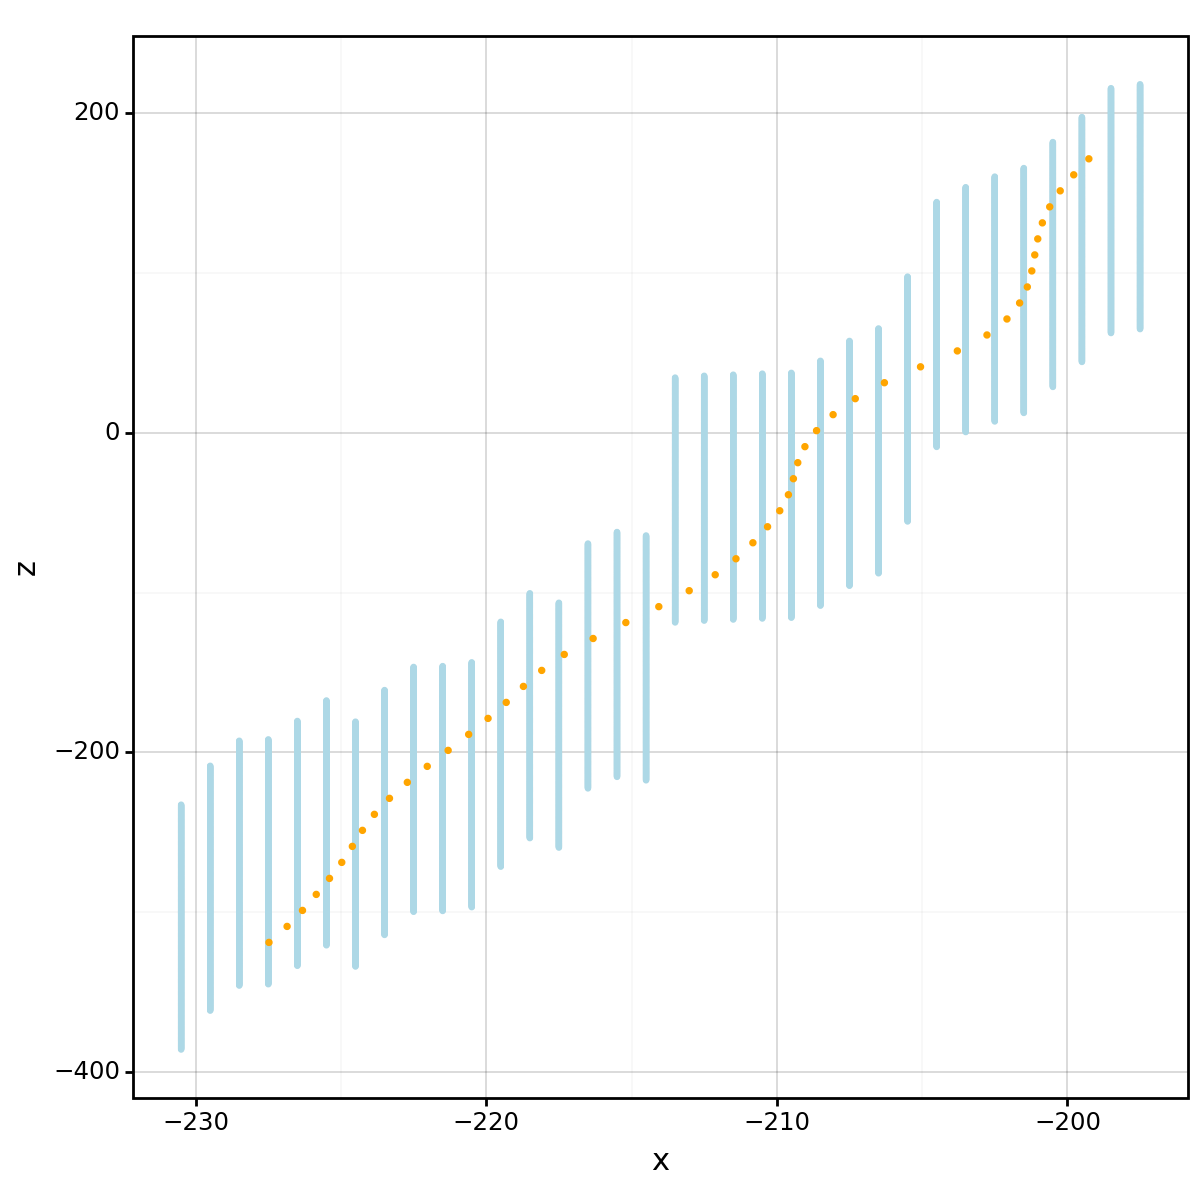

<Figure Size: (600 x 600)>

In [8]:
data = df[df["layer"] == 0][["x", "z"]].to_numpy()

fit = SplineFit(data, np.zeros(1), radius=25.0)
print(fit.npt)

fit.build_clusters(int(fit.npt / 2))
fit.order()
oc = fit.oc

dfc = pd.DataFrame(oc.value(np.arange(0, 1, 0.02)), columns=["x", "z"])
dfc["Type"] = "Ordering Curve"

print(fit.n_clusters)
p1 + geom_point(data=dfc, color="orange", size=0.5)